In [1]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [2]:
# ratings = pd.read_csv("https://s3-us-west-2.amazonaws.com/recommender-tutorial/ratings.csv")
# ratings.head()
# movies = pd.read_csv("https://s3-us-west-2.amazonaws.com/recommender-tutorial/movies.csv")
# movies.head()
# ratings.to_pickle('ratings.pkl')
# movies.to_pickle('movies.pkl')

In [3]:
ratings_df = pd.read_pickle('ratings.pkl')
ratings_df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [4]:
movies_df = pd.read_pickle('movies.pkl')
movies_df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


### EDA

In [5]:
combined_df = pd.merge(movies_df,ratings_df, on = 'movieId' )
combined_df

,movieId,title,genres,userId,rating,timestamp
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1,4.0,964982703
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,5,4.0,847434962
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,7,4.5,1106635946
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,15,2.5,1510577970
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,17,4.5,1305696483
...,...,...,...,...,...,...
100831,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy,184,4.0,1537109082
100832,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy,184,3.5,1537109545
100833,193585,Flint (2017),Drama,184,3.5,1537109805
100834,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation,184,3.5,1537110021


### Count and Mean for each movieId
* Count column has number of ratings for each movie
* Mean column will tell the average rating for a movieId

In [6]:
count_and_mean_df = combined_df.groupby(['movieId', 'title', 'genres'])['rating'].agg(['count', 'mean', 'sum'])
count_and_mean_df = count_and_mean_df.sort_values(by = 'count', ascending = False)
count_and_mean_df

,,,count,mean,sum
movieId,title,genres,,,
356,Forrest Gump (1994),Comedy|Drama|Romance|War,329,4.164134,1370.0
318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022,1404.0
296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307,4.197068,1288.5
593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,279,4.161290,1161.0
2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,278,4.192446,1165.5
...,...,...,...,...,...
4093,Cop (1988),Thriller,1,1.500000,1.5
4089,Born in East L.A. (1987),Comedy,1,2.000000,2.0
58351,City of Men (Cidade dos Homens) (2007),Drama,1,4.000000,4.0


In [7]:
userid_df = combined_df.groupby(['userId','title', 'genres'])['rating'].agg(['count', 'mean', 'sum'])
userid_df = userid_df.sort_values(by = 'count', ascending = False)
userid_df

count  \
userId title                                              genres                               
1      13th Warrior, The (1999)                           Action|Adventure|Fantasy         1   
434    No Country for Old Men (2007)                      Crime|Drama                      1   
       Mystic River (2003)                                Crime|Drama|Mystery              1   
       My Big Fat Greek Wedding (2002)                    Comedy|Romance                   1   
       Munich (2005)                                      Action|Crime|Drama|Thriller      1   
...                                                                                      ...   
227    No Direction Home: Bob Dylan (2005)                Documentary                      1   
       No Country for Old Men (2007)                      Crime|Drama                      1   
       Net, The (1995)                                    Action|Crime|Thriller            1   
       Motorcycle Diaries, The (Diarios de motocicleta... Adventure|Drama                  1   
610    xXx: State of the Union (2005)                     Action|Crime|Thriller            1   

                                                                                       mean  \
userId title                                              genres                              
1      13th Warrior, The (1999)                           Action|Adventure|Fantasy      4.0   
434    No Country for Old Men (2007)                      Crime|Drama                   5.0   
       Mystic River (2003)                                Crime|Drama|Mystery           4.5   
       My Big Fat Greek Wedding (2002)                    Comedy|Romance                2.5   
       Munich (2005)                                      Action|Crime|Drama|Thriller   4.0   
...                                                                                     ...   
227    No Direction Home: Bob Dylan (2005)                Documentary                   4.0   
       No Country for Old Men (2007)                      Crime|Drama                   4.0   
       Net, The (1995)                                    Action|Crime|Thriller         3.0   
       Motorcycle Diaries, The (Diarios de motocicleta... Adventure|Drama               4.5   
610    xXx: State of the Union (2005)                     Action|Crime|Thriller         1.5   

                                                                                       sum  
userId title                                              genres                            
1      13th Warrior, The (1999)                           Action|Adventure|Fantasy     4.0  
434    No Country for Old Men (2007)                      Crime|Drama                  5.0  
       Mystic River (2003)                                Crime|Drama|Mystery          4.5  
       My Big Fat Greek Wedding (2002)                    Comedy|Romance               2.5  
       Munich (2005)                                      Action|Crime|Drama|Thriller  4.0  
...                                                                                    ...  
227    No Direction Home: Bob Dylan (2005)                Documentary                  4.0  
       No Country for Old Men (2007)                      Crime|Drama                  4.0  
       Net, The (1995)                                    Action|Crime|Thriller        3.0  
       Motorcycle Diaries, The (Diarios de motocicleta... Adventure|Drama              4.5  
610    xXx: State of the Union (2005)                     Action|Crime|Thriller        1.5  

[100836 rows x 3 columns]

C:\Users\Arjun Janamatti\Anaconda3\envs\tf_nptel\lib\site-packages\seaborn\distributions.py:283: UserWarning: Data must have variance to compute a kernel density estimate.
  warnings.warn(msg, UserWarning)


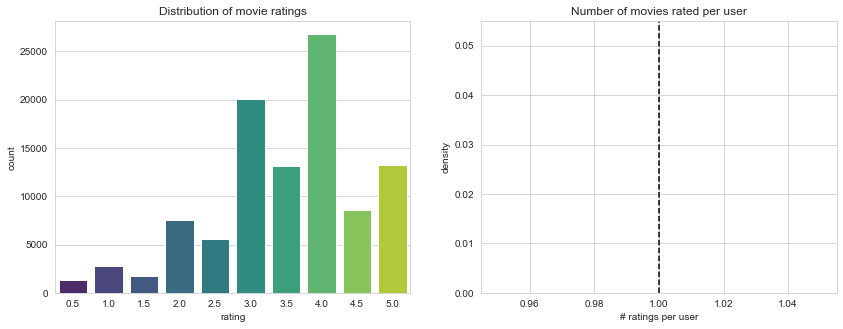

In [8]:
sns.set_style("whitegrid")
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
ax = sns.countplot(x="rating", data=ratings_df, palette="viridis")
plt.title("Distribution of movie ratings")

plt.subplot(1,2,2)
ax = sns.kdeplot(userid_df['count'], shade=True, legend=False)
plt.axvline(userid_df['count'].mean(), color="k", linestyle="--")
plt.xlabel("# ratings per user")
plt.ylabel("density")
plt.title("Number of movies rated per user")
plt.show()

### Considering movies which had minimum of 10 ratings

In [9]:
count_and_mean_df_min_10_reviews = count_and_mean_df[count_and_mean_df['count']>10]
count_and_mean_df_min_10_reviews

,,,count,mean,sum
movieId,title,genres,,,
356,Forrest Gump (1994),Comedy|Drama|Romance|War,329,4.164134,1370.0
318,"Shawshank Redemption, The (1994)",Crime|Drama,317,4.429022,1404.0
296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,307,4.197068,1288.5
593,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,279,4.161290,1161.0
2571,"Matrix, The (1999)",Action|Sci-Fi|Thriller,278,4.192446,1165.5
...,...,...,...,...,...
54190,Across the Universe (2007),Drama|Fantasy|Musical|Romance,11,4.045455,44.5
65261,Ponyo (Gake no ue no Ponyo) (2008),Adventure|Animation|Children|Fantasy,11,4.000000,44.0
3262,Twin Peaks: Fire Walk with Me (1992),Crime|Drama|Mystery|Thriller,11,3.409091,37.5


In [10]:
# lowest rated movie
lowest_rated_id = count_and_mean_df_min_10_reviews['mean'].idxmin()
combined_df[combined_df['movieId']==lowest_rated_id[0]]

,movieId,title,genres,userId,rating,timestamp
48299,2798,Problem Child (1990),Children|Comedy,135,1.0,1009690782
48300,2798,Problem Child (1990),Children|Comedy,217,1.0,955945592
48301,2798,Problem Child (1990),Children|Comedy,274,2.5,1172023939
48302,2798,Problem Child (1990),Children|Comedy,294,1.0,966597308
48303,2798,Problem Child (1990),Children|Comedy,307,2.0,1186172632
48304,2798,Problem Child (1990),Children|Comedy,313,3.0,1030558282
48305,2798,Problem Child (1990),Children|Comedy,387,1.5,1095117423
48306,2798,Problem Child (1990),Children|Comedy,477,0.5,1201158502
48307,2798,Problem Child (1990),Children|Comedy,479,1.0,1039360660
48308,2798,Problem Child (1990),Children|Comedy,599,2.0,1498510366


In [11]:
# highest rated movie
highest_rated_id = count_and_mean_df_min_10_reviews['mean'].idxmax()
combined_df[combined_df['movieId']==highest_rated_id[0]]

,movieId,title,genres,userId,rating,timestamp
22432,1041,Secrets & Lies (1996),Drama,74,5.0,1207499247
22433,1041,Secrets & Lies (1996),Drama,90,5.0,856354268
22434,1041,Secrets & Lies (1996),Drama,195,4.0,974709608
22435,1041,Secrets & Lies (1996),Drama,221,5.0,1111178190
22436,1041,Secrets & Lies (1996),Drama,275,5.0,1049078844
22437,1041,Secrets & Lies (1996),Drama,290,5.0,974938253
22438,1041,Secrets & Lies (1996),Drama,372,4.0,874415199
22439,1041,Secrets & Lies (1996),Drama,391,4.0,1032390066
22440,1041,Secrets & Lies (1996),Drama,474,4.5,1165539921
22441,1041,Secrets & Lies (1996),Drama,603,5.0,963179377


### Lets measure using Bayesian Average

Bayesian Average is defined as:

$r_{i} = \frac{C \times m + \Sigma{\text{reviews}}}{C+N}$

where $C$ represents our confidence, $m$ represents our prior, and $N$ is the total number of reviews for movie $i$. In this case, our prior will be the average rating across all movies. By defintion, C represents "the typical dataset size". Let's make $C$ be the average number of ratings for a given movie.

In [12]:
movie_stats = ratings_df.groupby('movieId')[['rating']].agg(['count', 'mean'])
movie_stats.columns = movie_stats.columns.droplevel()

In [13]:
C = movie_stats['count'].mean()
m = movie_stats['mean'].mean()

def bayesian_avg(ratings):
    bayesian_avg = (C*m+ratings.sum())/(C+ratings.count())
    return bayesian_avg

bayesian_avg_ratings = ratings_df.groupby('movieId')['rating'].agg(bayesian_avg).reset_index()
bayesian_avg_ratings.columns = ['movieId', 'bayesian_avg']
movie_stats = movie_stats.merge(bayesian_avg_ratings, on='movieId')

##### Top 5 best rated movies using Bayesian average

In [14]:
movie_stats = movie_stats.merge(movies_df[['movieId', 'title']])
movie_stats.sort_values('bayesian_avg', ascending=False).head()

,movieId,count,mean,bayesian_avg,title
277,318,317,4.429022,4.392070,"Shawshank Redemption, The (1994)"
659,858,192,4.289062,4.236457,"Godfather, The (1972)"
2224,2959,218,4.272936,4.227052,Fight Club (1999)
224,260,251,4.231076,4.192646,Star Wars: Episode IV - A New Hope (1977)
46,50,204,4.237745,4.190567,"Usual Suspects, The (1995)"


##### Top 5 worst rated movies using Bayesian average

In [15]:
movie_stats.sort_values('bayesian_avg', ascending=True).head()

,movieId,count,mean,bayesian_avg,title
1172,1556,19,1.605263,2.190377,Speed 2: Cruise Control (1997)
2679,3593,19,1.657895,2.224426,Battlefield Earth (2000)
1372,1882,33,1.954545,2.267268,Godzilla (1998)
1144,1499,27,1.925926,2.296800,Anaconda (1997)
1988,2643,16,1.687500,2.306841,Superman IV: The Quest for Peace (1987)


We will be using a technique called collaborative filtering to generate user recommendations. This technique is based on the assumption of "homophily" - similar users like similar things. Collaborative filtering is a type of unsupervised learning that makes predictions about the interests of a user by learning from the interests of a larger population.

The first step of collaborative filtering is to transform our data into a user-item matrix - also known as a "utility" matrix. In this matrix, rows represent users and columns represent items. The beauty of collaborative filtering is that it doesn't require any information about the users or items to generate recommendations.

The create_X() function outputs a sparse matrix X with four mapper dictionaries:

    user_mapper: maps user id to user index
    movie_mapper: maps movie id to movie index
    user_inv_mapper: maps user index to user id
    movie_inv_mapper: maps movie index to movie id

We need these dictionaries because they map which row and column of the utility matrix corresponds to which user ID and movie ID, respectively.

The X (user-item) matrix is a scipy.sparse.csr_matrix which stores the data sparsely.


In [16]:
from scipy.sparse import csr_matrix

def create_X(df):
    """
    Generates a sparse matrix from ratings dataframe.
    
    Args:
        df: pandas dataframe
    
    Returns:
        X: sparse matrix
        user_mapper: dict that maps user id's to user indices
        user_inv_mapper: dict that maps user indices to user id's
        movie_mapper: dict that maps movie id's to movie indices
        movie_inv_mapper: dict that maps movie indices to movie id's
    """
    N = df['userId'].nunique()
    M = df['movieId'].nunique()

    user_mapper = dict(zip(np.unique(df["userId"]), list(range(N))))
    movie_mapper = dict(zip(np.unique(df["movieId"]), list(range(M))))
    
    user_inv_mapper = dict(zip(list(range(N)), np.unique(df["userId"])))
    movie_inv_mapper = dict(zip(list(range(M)), np.unique(df["movieId"])))
    
    user_index = [user_mapper[i] for i in df['userId']]
    movie_index = [movie_mapper[i] for i in df['movieId']]

    X = csr_matrix((df["rating"], (movie_index, user_index)), shape=(M, N))
    
    return X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper

In [17]:
X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper = create_X(ratings_df)

In [18]:
sparsity = X.count_nonzero()/(X.shape[0]*X.shape[1])

print(f"Matrix sparsity: {round(sparsity*100,2)}%")

Matrix sparsity: 1.7%


##### Writing the matrix to a file

In [19]:
from scipy.sparse import save_npz

save_npz('user_item_matrix.npz', X)

This approach looks for the $k$ nearest neighbours of a given movie by identifying $k$ points in the dataset that are closest to movie $m$. kNN makes use of distance metrics such as:

1. Cosine similarity
2. Euclidean distance
3. Manhattan distance
4. Pearson correlation

Although difficult to visualize, we are working in a M-dimensional space where M represents the number of movies in our X matrix.

In [20]:
from sklearn.neighbors import NearestNeighbors

def find_similar_movies(movie_id, X, k, metric='cosine', show_distance=False):
    """
    Finds k-nearest neighbours for a given movie id.
    
    Args:
        movie_id: id of the movie of interest
        X: user-item utility matrix
        k: number of similar movies to retrieve
        metric: distance metric for kNN calculations
    
    Returns:
        list of k similar movie ID's
    """
    neighbour_ids = []
    
    movie_ind = movie_mapper[movie_id]
    movie_vec = X[movie_ind]
    k+=1
    kNN = NearestNeighbors(n_neighbors=k, algorithm="brute", metric=metric)
    kNN.fit(X)
    if isinstance(movie_vec, (np.ndarray)):
        movie_vec = movie_vec.reshape(1,-1)
    neighbour = kNN.kneighbors(movie_vec, return_distance=show_distance)
    for i in range(0,k):
        n = neighbour.item(i)
        neighbour_ids.append(movie_inv_mapper[n])
    neighbour_ids.pop(0)
    return neighbour_ids

In [21]:
movie_titles = dict(zip(movies_df['movieId'], movies_df['title']))

movie_id = 10

similar_ids = find_similar_movies(movie_id, X, k=10)
movie_title = movie_titles[movie_id]

print(f"Because you watched {movie_title}")
for i in similar_ids:
    print(movie_titles[i])

Because you watched GoldenEye (1995)
Die Hard: With a Vengeance (1995)
True Lies (1994)
Clear and Present Danger (1994)
Speed (1994)
Batman (1989)
Stargate (1994)
Jurassic Park (1993)
Batman Forever (1995)
Mission: Impossible (1996)
Terminator 2: Judgment Day (1991)


In [22]:
movie_titles = dict(zip(movies_df['movieId'], movies_df['title']))

movie_id = 10

similar_ids = find_similar_movies(movie_id, X, k=10, metric='euclidean')
movie_title = movie_titles[movie_id]

print(f"Because you watched {movie_title}")
for i in similar_ids:
    print(movie_titles[i])

Because you watched GoldenEye (1995)
Cliffhanger (1993)
Batman Forever (1995)
Judge Dredd (1995)
Clear and Present Danger (1994)
Mortal Kombat (1995)
Tomorrow Never Dies (1997)
Demolition Man (1993)
Die Hard: With a Vengeance (1995)
Beverly Hills Cop III (1994)
Species (1995)
